# Mini Projeto Avaliativo - Módulo 2

## Predição de números

**Problema preditivo:** Pipeline Preditivo Multiclasse ponta a ponta capaz de classificar dígitos manuscritos a partir do dataset MNIST (mnist_784).

# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Baixando o MNIST oficial do OpenML
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

# Separando Entradas (X) e Rótulos (y)
# Como o target vem como string ('0', '1', ...), eu vou converter para inteiros
X, y = mnist.data, mnist.target.astype(np.uint8)

# Exibe as dimensões das matrizes para confirmar o formato do dataset
print(f"Dimensão de X: {X.shape}")
print(f"Dimensão de y: {y.shape}")

# Verifica a distribuição das classes de 0 a 9 para confirmar o balanceamento e o percentual de cada digito no dataset
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição das classes (0 a 9):")
for classe, quantidade in zip(classes, contagens):
    percentual = (quantidade / len(y)) * 100
    print(f"Classe {classe}: {quantidade} amostras ({percentual:.2f}%)")



Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensão de X: (70000, 784)
Dimensão de y: (70000,)

Distribuição das classes (0 a 9):
Classe 0: 6903 amostras (9.86%)
Classe 1: 7877 amostras (11.25%)
Classe 2: 6990 amostras (9.99%)
Classe 3: 7141 amostras (10.20%)
Classe 4: 6824 amostras (9.75%)
Classe 5: 6313 amostras (9.02%)
Classe 6: 6876 amostras (9.82%)
Classe 7: 7293 amostras (10.42%)
Classe 8: 6825 amostras (9.75%)
Classe 9: 6958 amostras (9.94%)


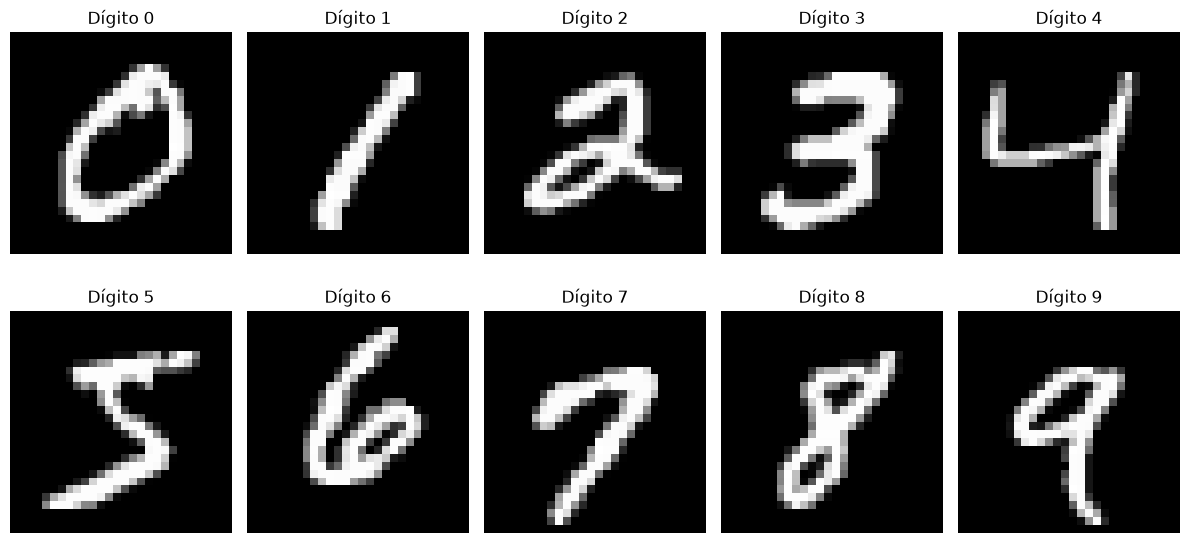

In [11]:
# Gera uma grade visual com exemplos de imagens de cada dígito do MNIST
# e mostra o rótulo original correspondente.

plt.figure(figsize=(12, 6))

# Seleciona um exemplo de cada classe de 0 a 9
indices_por_classe = []
for classe in range(10):
    indices = np.where(y == classe)[0]
    indices_por_classe.append(indices[0])

for i, idx in enumerate(indices_por_classe, start=1):
    plt.subplot(2, 5, i)
    imagem_exemplo = X[idx].reshape(28, 28)

    #Se usar cmap='binary': O gráfico mostrará dígitos pretos em fundo branco.
    #Se usar cmap='gray': O gráfico mostrará o formato real do dataset (dígitos brancos em fundo preto)
    plt.imshow(imagem_exemplo, cmap='gray')
    plt.title(f'Dígito {i - 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### Interpretação da estrutura dos dados

O dataset MNIST é composto por imagens em escala de cinza de resolução 28 x 28 pixels. Cada pixel representa um valor de intensidade entre 0 e 255:

- `0` = pixel completamente preto
- `255` = pixel completamente branco
- valores intermediários representam tons de cinza

Como cada imagem tem 28 linhas e 28 colunas, ela pode ser vista como uma matriz 28 x 28. Para o modelo de Machine Learning, essa matriz precisa ser transformada em um vetor unidimensional, contendo todos os 784 valores dos pixels em sequência.

Assim, cada imagem original é convertida em uma representação vetorial com 784 features, ou seja:

- imagem 28 x 28 = 784 pixels
- vetor 1 x 784 = 784 features

Essa transformação é importante porque os modelos de redes neurais e outros algoritmos de aprendizado supervisionado exigem entradas numéricas em formato vetorial.

No notebook, essa conversão é feita quando usamos:

```python
dados_imagem = np.array(imagem_final) / 255.0
dados_prontos = dados_imagem.reshape(1, 784)
```

Nesse passo:

- `np.array(imagem_final)` transforma a imagem em uma matriz NumPy
- `/ 255.0` normaliza os valores para o intervalo entre 0 e 1
- `reshape(1, 784)` transforma a matriz 28 x 28 em um vetor de 784 elementos

Esse processo permite que o modelo entenda cada imagem como um conjunto de 784 atributos numéricos, sendo cada atributo a intensidade de um pixel específico.

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados


### Como a divisão foi feita

A divisão foi realizada em duas etapas, e isso é o motivo de o valor parecer "12,5%" na segunda etapa:

1. Primeiro, o dataset foi dividido em 80% e 20%:
   - 20% foi reservado para o conjunto de teste (test_size=0.2)
   - os outros 80% ficaram para treino + validação

2. Em seguida, dos 80% que sobraram, foi feita outra divisão:
   - 12,5% desse restante foi usado para validação (test_size=0.125)
   - o restante (87,5%) ficou para treino

Isso resulta no percentual final sobre o dataset inteiro:

- Teste: 20%
- Validação: 10%
- Treino: 70%

Cálculo:

- 12,5% de 80% = 10%
- 80% - 10% = 70%

Ou seja, a segunda divisão usa 12,5% sobre o conjunto restante, mas no total isso corresponde a 10% do dataset original.

Portanto, a divisão final fica:

- 70% treino
- 10% validação
- 20% teste

Essa estratégia ajuda a manter a proporção das classes em todos os conjuntos, graças ao uso de `stratify=y`.

In [12]:
# Divisão estratificada do dataset em treino, validação e teste
# Primeiro: separa 20% para teste, mantendo a proporção das classes (stratify=y)
# Depois: separa 12.5% do restante para validação, e o restante (70%) fica para treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Validação: X={X_val.shape}, y={y_val.shape}")
print(f"Teste: X={X_test.shape}, y={y_test.shape}")


Treino: X=(49000, 784), y=(49000,)
Validação: X=(7000, 784), y=(7000,)
Teste: X=(14000, 784), y=(14000,)


In [13]:
# Verifica a distribuição das classes em treino, validação e teste
for nome, y_split in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    classes, contagens = np.unique(y_split, return_counts=True)
    print(f"\n{nome}:")
    for classe, quantidade in zip(classes, contagens):
        percentual = (quantidade / len(y_split)) * 100
        print(f"  Classe {classe}: {quantidade} amostras ({percentual:.2f}%)")



Treino:
  Classe 0: 4832 amostras (9.86%)
  Classe 1: 5514 amostras (11.25%)
  Classe 2: 4893 amostras (9.99%)
  Classe 3: 4999 amostras (10.20%)
  Classe 4: 4777 amostras (9.75%)
  Classe 5: 4419 amostras (9.02%)
  Classe 6: 4813 amostras (9.82%)
  Classe 7: 5105 amostras (10.42%)
  Classe 8: 4777 amostras (9.75%)
  Classe 9: 4871 amostras (9.94%)

Validação:
  Classe 0: 690 amostras (9.86%)
  Classe 1: 788 amostras (11.26%)
  Classe 2: 699 amostras (9.99%)
  Classe 3: 714 amostras (10.20%)
  Classe 4: 682 amostras (9.74%)
  Classe 5: 631 amostras (9.01%)
  Classe 6: 688 amostras (9.83%)
  Classe 7: 729 amostras (10.41%)
  Classe 8: 683 amostras (9.76%)
  Classe 9: 696 amostras (9.94%)

Teste:
  Classe 0: 1381 amostras (9.86%)
  Classe 1: 1575 amostras (11.25%)
  Classe 2: 1398 amostras (9.99%)
  Classe 3: 1428 amostras (10.20%)
  Classe 4: 1365 amostras (9.75%)
  Classe 5: 1263 amostras (9.02%)
  Classe 6: 1375 amostras (9.82%)
  Classe 7: 1459 amostras (10.42%)
  Classe 8: 1365 amo

### Por que a normalização é importante?

A normalização dos pixels é uma etapa essencial em problemas de classificação com imagens, especialmente quando o modelo será treinado com redes neurais ou algoritmos que dependem de escala e distância.

No MNIST, cada pixel original está no intervalo de 0 a 255. Se esse valor fosse mantido assim, alguns recursos teriam magnitudes muito maiores do que outros, e isso pode prejudicar a convergência do modelo.

Ao dividir os valores por 255.0, os pixels passam a ficar no intervalo de 0.0 a 1.0. Isso faz com que as entradas tenham uma escala mais homogênea, o que ajuda o modelo a aprender de forma mais estável.

Essa etapa é especialmente importante para:

- modelos lineares, porque eles são sensíveis à escala das variáveis e podem ter dificuldades em ajustar pesos corretamente quando os atributos têm magnitudes muito diferentes;
- algoritmos baseados em distância, como k-NN, porque a distância entre pontos pode ser dominada por atributos de maior magnitude se os dados não forem normalizados;
- redes neurais, porque a normalização acelera a convergência e reduz problemas de atualização de pesos durante o treinamento.

Em resumo, a normalização torna o espaço de entrada mais uniforme e favorece o aprendizado eficiente, evitando que recursos com maior escala dominem os cálculos do modelo.

No notebook, isso é feito por:

```python
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0
```

Essa operação mantém a estrutura dos dados, mas coloca os valores em uma escala adequada para o treinamento.

In [14]:
# Normalização: pixels variam de 0 a 255 e são escalados para o intervalo [0.0, 1.0]
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0

# Fase 3: Implementação e Treinamento dos 3 Modelos

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Random Forest para classificação multiclasse do MNIST
# Ajuste justificado dos hiperparâmetros:
# - n_estimators=300: aumenta a quantidade de árvores para reduzir variância
#   e deixar a previsão mais estável, especialmente em dados com muitas features.

# - max_depth=20: limita a profundidade das árvores para evitar overfitting,
#   preservando capacidade suficiente para aprender padrões dos dígitos.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("Treinando o modelo Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Avaliação no conjunto de validação
val_pred = rf_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred))

#print("\nMatriz de confusão na validação:")
#print(confusion_matrix(y_val, val_pred))

# Predição no conjunto de teste para avaliação final
pred_test = rf_model.predict(X_test_scaled)
print("\nAcurácia no teste:", accuracy_score(y_test, pred_test))


Treinando o modelo Random Forest...

Acurácia na validação: 0.9671

Relatório de classificação na validação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       690
           1       0.98      0.99      0.98       788
           2       0.95      0.98      0.96       699
           3       0.96      0.94      0.95       714
           4       0.97      0.96      0.97       682
           5       0.97      0.96      0.96       631
           6       0.97      0.99      0.98       688
           7       0.97      0.96      0.96       729
           8       0.96      0.96      0.96       683
           9       0.94      0.95      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000


Matriz de confusão na validação:
[[685   0   0   0   1   1   1   0   2   0]
 [  0 777   4   1   0   1   1   2   1   1]
 [  1   0 68

### KNN (K-Nearest Neighbors)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# KNN (K-Nearest Neighbors) para classificação multiclasse do MNIST
# Ajuste justificado dos hiperparâmetros:
# - n_neighbors=5: um valor moderado reduz ruído e mantém o modelo sensível
#   aos vizinhos mais próximos, sem ficar excessivamente sensível ao conjunto.

# - weights='distance': dá maior importância aos vizinhos mais próximos,
#   o que costuma melhorar a acurácia em dados como MNIST, onde o padrão
#   visual mais próximo geralmente é o mais relevante.
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

print("Treinando o modelo KNN...")
knn_model.fit(X_train_scaled, y_train)

# Avaliação no conjunto de validação
val_pred = knn_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred))

#print("\nMatriz de confusão na validação:")
#print(confusion_matrix(y_val, val_pred))

# Predição no conjunto de teste para avaliação final
pred_test = knn_model.predict(X_test_scaled)
print("\nAcurácia no teste:", accuracy_score(y_test, pred_test))


Treinando o modelo KNN...

Acurácia na validação: 0.9714

Relatório de classificação na validação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       690
           1       0.95      0.99      0.97       788
           2       0.98      0.97      0.98       699
           3       0.97      0.96      0.97       714
           4       0.99      0.96      0.97       682
           5       0.97      0.97      0.97       631
           6       0.98      0.99      0.98       688
           7       0.97      0.97      0.97       729
           8       0.99      0.93      0.96       683
           9       0.94      0.97      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000


Acurácia no teste: 0.9703571428571428


In [8]:
from tkinter import Tk
from tkinter.filedialog import askopenfilename

root = Tk()
root.withdraw()
root.attributes('-topmost', True)

caminho_imagem = askopenfilename(
    title='Selecione uma imagem',
    filetypes=[
        ('Imagens', '*.png *.jpg *.jpeg *.bmp *.gif *.tif *.tiff'),
        ('Todos os arquivos', '*.*')
    ]
)

root.destroy()

if not caminho_imagem:
    raise ValueError('Nenhuma imagem foi selecionada.')

# Carrega a imagem escolhida e converte para escala de cinza
imagem = Image.open(caminho_imagem).convert('L')

# Ajusta o contraste para deixar o traço do dígito mais nítido
imagem = ImageOps.autocontrast(imagem)

# Converte a imagem para um padrão mais parecido com o MNIST:
# fundo branco (255) e traço preto (0), o que ajuda o modelo a reconhecer melhor
imagem = imagem.point(lambda p: 255 if p > 180 else 0, mode='1').convert('L')

# Recorta a região relevante da imagem para remover espaços vazios
bbox = imagem.getbbox()
if bbox:
    imagem_cortada = imagem.crop(bbox)
else:
    imagem_cortada = imagem

# Redimensiona a imagem para 20x20 mantendo a proporção e depois centraliza em 28x28
imagem_cortada = imagem_cortada.resize((20, 20), Image.Resampling.LANCZOS)
imagem_final = Image.new('L', (28, 28), color=255)
pos_x = (28 - imagem_cortada.width) // 2
pos_y = (28 - imagem_cortada.height) // 2
imagem_final.paste(imagem_cortada, (pos_x, pos_y))

# A variável `imagem` continua sendo usada nas células seguintes
imagem = imagem_final

print(f'Caminho selecionado: {caminho_imagem}')
imagem

ValueError: Nenhuma imagem foi selecionada.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from modeling.train import (
    train_model,
    evaluate_model,
    train_model_GradientBoosting,
    evaluate_model_GradientBoosting,
    cross_validate_model,
)



In [ ]:
imagem

In [ ]:
# Se a imagem tiver fundo preto (0), usamos o bbox direto:
bbox = imagem.getbbox()
if bbox:
    imagem_cortada = imagem.crop(bbox)
else:
    imagem_cortada = imagem

In [ ]:
imagem_cortada

In [ ]:
# Redimensionar o traço para no máximo 20x20, isso mantendo a proporção original
imagem_cortada.thumbnail((20, 20), Image.Resampling.LANCZOS)

In [ ]:
# Criar uma tela preta de 28x28 e colar o traço no centro exato
imagem_final = Image.new('L', (28, 28), color=0)
pos_x = (28 - imagem_cortada.width) // 2
pos_y = (28 - imagem_cortada.height) // 2
imagem_final.paste(imagem_cortada, (pos_x, pos_y))

In [ ]:
# Normalizar e preparar para o modelo
dados_imagem = np.array(imagem_final) / 255.0
dados_prontos = dados_imagem.reshape(1, 784)

In [ ]:
dados_prontos

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [ ]:
# Predição
probabilidades = modelo_mnist.predict(dados_prontos)
predicao = np.argmax(probabilidades)
certeza = probabilidades[0][predicao] * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step



O modelo identificou o número: 0
Confiança: 94.56%



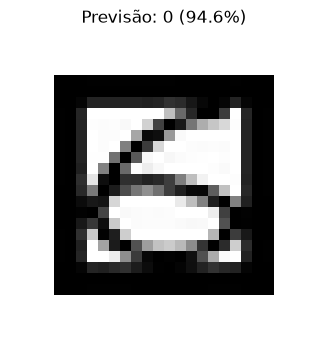

In [ ]:
print(f"\nO modelo identificou o número: {predicao}")
print(f"Confiança: {certeza:.2f}%\n")

# 7. Visualizar a imagem centralizada como o MNIST espera
plt.figure(figsize=(4, 4))
plt.imshow(dados_imagem, cmap='binary')
plt.title(f"Previsão: {predicao} ({certeza:.1f}%)")
plt.axis('off')
plt.show()